# ПРИМЕР 2

## Оценка параметров функционирования сложной модели НРС при различных режимах работы
![модель НРС](imgs/nrs_1.jpg)
Схема НРС состоит из:
* 1 источника в виде насоса ПА
* 2 магистральных рукавных линий
* 2 рукавных разветвлений
* 5 рабочих рукавных линий
* 5 приборов подачи воды

Подключение библиотек

In [1]:
from nrs import NRS_Model, Element, NRS_Revision, NRS_Observer_E    # классы НРС
from nrs import NRS_Data as nd                                      # Табличные данные НРС
from nrs import q_out_simple, q_out_nozzle                          # модели расчета параметров
import matplotlib.pyplot as plt                                     # библиотеки для отрисовки получаемых данных

In [2]:
# Вычисляем проводимости гладкоствольных насадков для стволов Б (13мм) и А (19мм)
p_B = NRS_Revision.calc_p(3.7, 40)
p_A = NRS_Revision.calc_p(7.4, 40)

# Эксперименты

## Состав модели:

* Источник (Насос): АЦ-40
* Магистральная рукавная линия (МРЛ Н-Р1): 3 пожарные напорные рукава диаметром 77мм
* Магистральная рукавная линия (МРЛ Р1-Р2): 3 пожарные напорные рукава диаметром 77мм
* Рукавное разветвление (Р1): Стандартное
* Рабочая рукавная линия (РРЛ Р1-Ств1): 3 пожарные напорные рукава диаметром 51мм
* Ствол 1 (Ств1): Ручной ствол "Б"
* Рабочая рукавная линия (РРЛ Р1-Ств2): 1 пожарные напорные рукава диаметром 51мм
* Ствол 2 (Ств2): Ручной ствол "Б"
* Рукавное разветвление (Р2): Стандартное
* Рабочая рукавная линия (РРЛ Р2-Ств3): 1 пожарные напорные рукава диаметром 51мм
* Ствол 3 (Ств3): Ручной ствол "Б"
* Рабочая рукавная линия (РРЛ Р2-Ств4): 1 пожарные напорные рукава диаметром 77мм
* Ствол 4 (Ств4): Ручной ствол "А"
* Рабочая рукавная линия (РРЛ Р2-Ств5): 3 пожарные напорные рукава диаметром 51мм
* Ствол 5 (Ств5): Ручной ствол "Б"

## Эксперимент 1-1


Условия:
* Стартовый напор на насосе - 40м

Задача:
* Рассчитать общий расход модели
* Рассчитать расходы на приборах подачи воды

In [4]:
# Создаем модель НРС:
model = NRS_Model('Модель от одного насоса к пяти стволам через два разветвления')

# Создаем элементы модели:
pump = Element('Н1', 0, H_add=40)                                       # Насос
hoseM_1 = Element('МРЛ Н-Р1', 1, s=nd.ss["77"], n=3)                    # магистральная рукавная линия №1 - от насоса к разветвлению №1

splitter_1 = Element('Р1', 1, ro=3)                                           # разветвление №1
hoseW_11 = Element('РРЛ Р1-1', 1, s=nd.ss["51"], n=3)                   # рабочая рукавная линия от разветвления №1 к стволу №1
nozzle_11 = Element('Ствол Р1-1(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №1
hoseW_12 = Element('РРЛ Р1-2', 1, s=nd.ss["51"], n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №2
nozzle_12 = Element('Ствол Р1-2(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №2
hoseM_12 = Element('МРЛ Р1-Р2', 1, s=nd.ss["77"], n=3)                  # магистральная рукавная линия №2 - от разветвления №1 к разветвлению №2

splitter_2 = Element('Р2', 1, ro=3)                                           # разветвление №2
hoseW_21 = Element('РРЛ Р2-1', 1, s=nd.ss["51"], n=1)                   # рабочая рукавная линия от разветвления №2 к стволу №3
nozzle_21 = Element('Ствол Р2-1(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №3
hoseW_22 = Element('РРЛ Р2-2', 1, s=nd.ss["77"], n=1)                   # рабочая рукавная линия от разветвления №2 к стволу №4
nozzle_22 = Element('Ствол Р2-2(А)', 2, p=p_A, q_out = q_out_nozzle)   # ствол №4
hoseW_23 = Element('РРЛ Р2-3', 1, s=nd.ss["51"], n=3)                   # рабочая рукавная линия от разветвления №2 к стволу №5
nozzle_23 = Element('Ствол Р2-3(Б)', 2, p=p_B, q_out = q_out_nozzle)  # ствол №5

# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hoseM_1).append(splitter_1).append(hoseM_12).append(splitter_2)     # Насос-МРЛ1-Разветвление№1-МРЛ2-Разветвление№2

splitter_1.append(hoseW_11).append(nozzle_11)   # Рукавная линия от разветвления №1 к стволу №1
splitter_1.append(hoseW_12).append(nozzle_12)   # Рукавная линия от разветвления №1 к стволу №2

splitter_2.append(hoseW_21).append(nozzle_21)   # Рукавная линия от разветвления №2 к стволу №3
splitter_2.append(hoseW_22).append(nozzle_22)   # Рукавная линия от разветвления №2 к стволу №4
splitter_2.append(hoseW_23).append(nozzle_23)   # Рукавная линия от разветвления №2 к стволу №5

# Добавляем обозревателей:
NRS_Observer_E(pump, ['q', 'H_add'])             # Для насоса
NRS_Observer_E(nozzle_11, ['q', 'H_in'])         # Для ствола №1
NRS_Observer_E(nozzle_12, ['q', 'H_in'])         # Для ствола №2
NRS_Observer_E(nozzle_21, ['q', 'H_in'])         # Для ствола №3
NRS_Observer_E(nozzle_22, ['q', 'H_in'])         # Для ствола №4
NRS_Observer_E(nozzle_23, ['q', 'H_in'])         # Для ствола №5

# Строим модель и инициируем обозревателей:
model.build(pump, interpretate=True)
model.observersInit()

# Расчет НРС:
model, r = model.calc(accuracy=0.05, fixStates=True)

# Печать результата расчета
print('=== Qобщ=' + str(model.summaryQ()) + 'л/с')
print(f'итераций {r['iters']}')

=== Qобщ=16.67482736678151л/с
итераций 27


In [5]:
# Печать описания модели
NRS_Revision.print_model_elements(model)

Модель от одного насоса к пяти стволам через два разветвления
all:
  Н1
  МРЛ Н-Р1
  Р1
  МРЛ Р1-Р2
  Р2
  РРЛ Р2-1
  Ствол Р2-1(Б)
  РРЛ Р2-2
  Ствол Р2-2(А)
  РРЛ Р2-3
  Ствол Р2-3(Б)
  РРЛ Р1-1
  Ствол Р1-1(Б)
  РРЛ Р1-2
  Ствол Р1-2(Б)
in:
  Н1
out:
  Ствол Р2-1(Б)
  Ствол Р2-2(А)
  Ствол Р2-3(Б)
  Ствол Р1-1(Б)
  Ствол Р1-2(Б)


In [6]:
def plotModelState():
    '''
        Функция построения итоговых графиков:
    '''

    # Расход всей системы
    plt.figure(figsize=(12, 8))
    plt.plot(pump.history()['q'], label='НРС в целом')

    plt.legend(title='Производительность НРС:')
    plt.xlabel('итерации')
    plt.ylabel('Q, л/с')
    plt.show()

    # Напоры и расходы на стволах
    plt.figure(figsize=(12, 8))
    plt.plot(nozzle_11.history()['q'], label=nozzle_11.name)
    plt.plot(nozzle_12.history()['q'], label=nozzle_12.name)
    plt.plot(nozzle_21.history()['q'], label=nozzle_21.name)
    plt.plot(nozzle_22.history()['q'], label=nozzle_22.name)
    plt.plot(nozzle_23.history()['q'], label=nozzle_23.name)

    plt.legend(title='Производительность стволов:')
    plt.xlabel('итерации')
    plt.ylabel('Q, л/с')
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.plot(nozzle_11.history()['H_in'], label=nozzle_11.name)
    plt.plot(nozzle_12.history()['H_in'], label=nozzle_12.name)
    plt.plot(nozzle_21.history()['H_in'], label=nozzle_21.name)
    plt.plot(nozzle_22.history()['H_in'], label=nozzle_22.name)
    plt.plot(nozzle_23.history()['H_in'], label=nozzle_23.name)

    plt.legend(title='Напоры на стволах:')
    plt.xlabel('итерации')
    plt.ylabel('Н, м')

    # fig.tight_layout()
    plt.show()

def printElementsQ():
    ''' Печать расходов на элементах модели '''
    print("Производительность насоса: ", round(pump.get_q_out(), 2), "л/с")
    print(f"Производительность {nozzle_11.name}: {round(nozzle_11.get_q_out() , 2)} л/с")
    print(f"Производительность {nozzle_12.name}: {round(nozzle_12.get_q_out() , 2)} л/с")
    print(f"Производительность {nozzle_21.name}: {round(nozzle_21.get_q_out() , 2)} л/с")
    print(f"Производительность {nozzle_22.name}: {round(nozzle_22.get_q_out() , 2)} л/с")
    print(f"Производительность {nozzle_23.name}: {round(nozzle_23.get_q_out() , 2)} л/с")

### Фоновое приведение модели в стационарное состояние, до точности 0,05л/с:

In [ ]:
# Основной вариант
model.calc(accuracy=0.05, fixStates=True)
# Расчет модели для 10 итераций
# model.calc(iters=10, fixStates=True)

print(f'Qобщ = {round(model.summaryQ(),2)} л/с')

Qобщ = 16.67 л/с


Альтернативный вариант

In [8]:
# Расчет модели для 10 итераций
model.calc(iters=10, fixStates=True)

print(f'Qобщ = {round(model.summaryQ(),2)} л/с')

Qобщ = 16.66 л/с


In [7]:
# Печать состояния насоса
print("="*10 + " Состояние насоса " + "="*10)
NRS_Revision.print_element_state(pump)

========== Состояние насоса ==========
elements_next: [<nrs.Element object at 0x000001B562FACFB0>]
elements_previous: []
type: 0
name: Н1
q: 16.67482736678151
s: 0
H_in: 0
h: 0.0
z: 0
p: 1
n: 1
q_out: <function q_out_simple at 0x000001B561F57060>
H_add: 40
observer: <nrs.NRS_Observer_E object at 0x000001B5632368A0>
l: 0
ri: 1
ro: 1
H_out: 40.0


In [8]:
# Печать состояния ствола №3 (от 2 разветвления, ствол №1)
print("="*10 + " Состояние ствола №3 " + "="*10)
NRS_Revision.print_element_state(nozzle_21)

========== Состояние ствола №3 ==========
elements_next: []
elements_previous: [<nrs.Element object at 0x000001B5632367B0>]
type: 2
name: Ствол Р2-1(Б)
q: 2.7072288307337433
s: 0
H_in: 21.414427880075944
h: 0
z: 0
p: 0.5850213671311502
n: 1
q_out: <function q_out_nozzle at 0x000001B561F57F60>
H_add: 0
observer: <nrs.NRS_Observer_E object at 0x000001B563236960>
l: 0
ri: 1
ro: 1


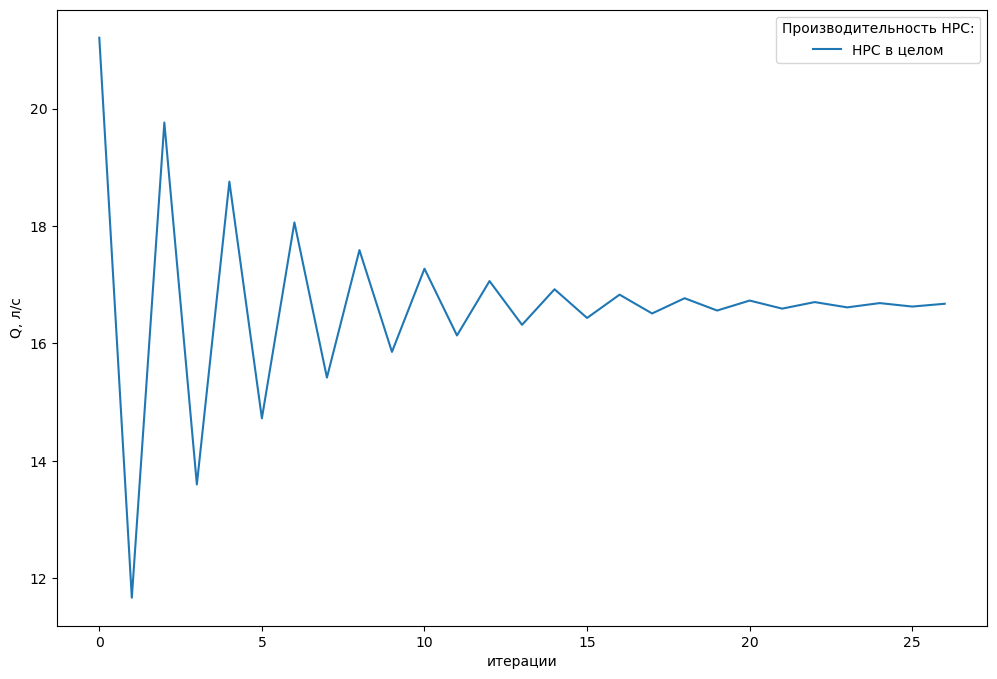

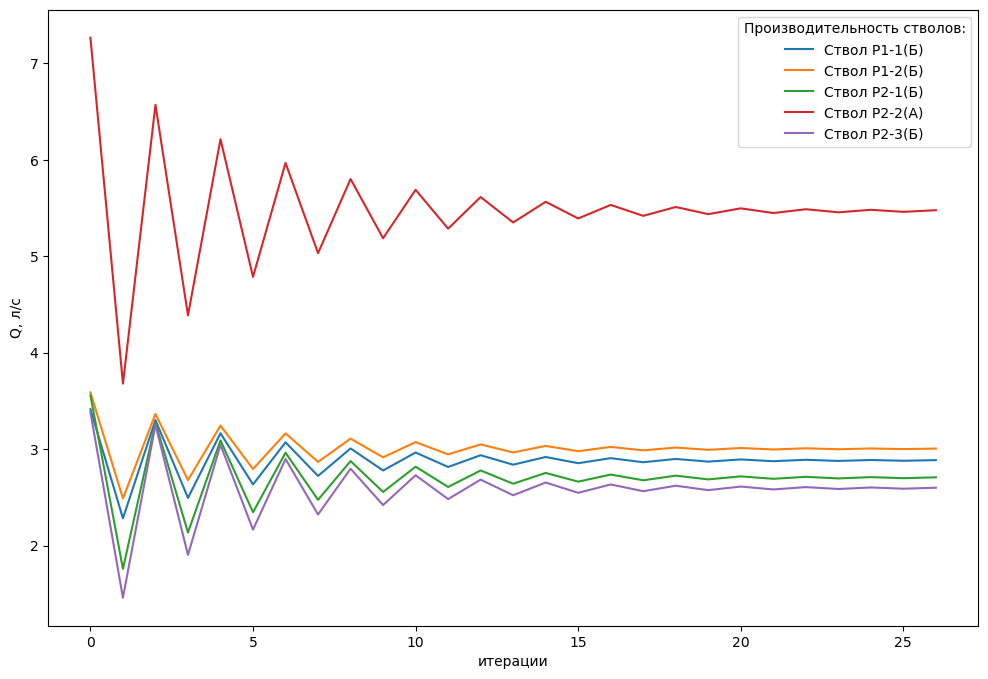

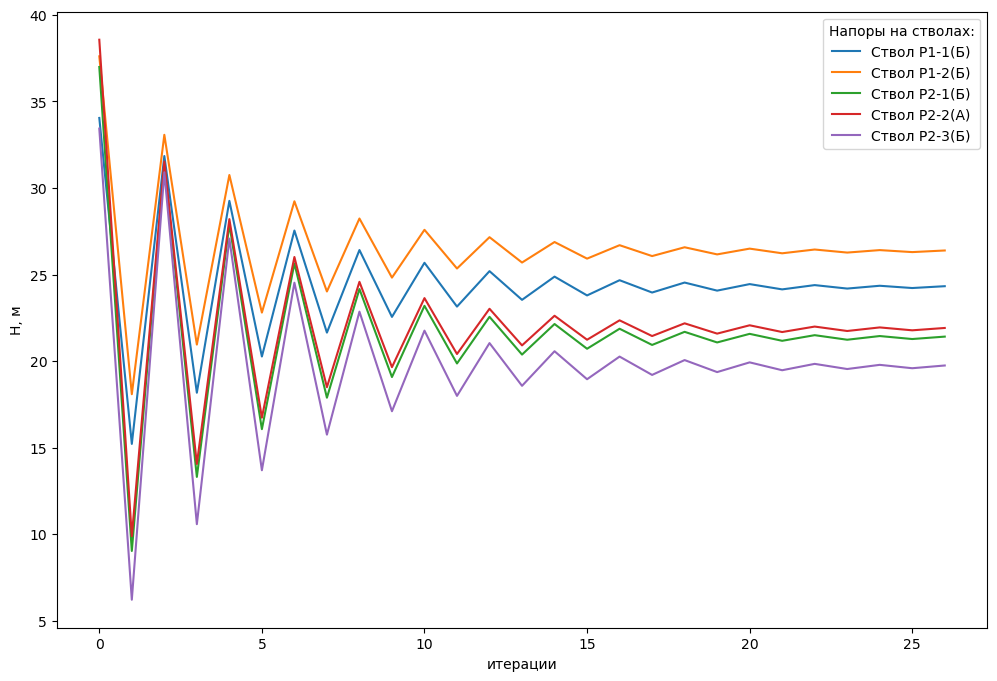

In [9]:
# Выводим графики (процесса приведения модели в стационарное состояние)
plotModelState()

In [17]:
# Итоговые расходы:
printElementsQ()

Производительность насоса:  16.66 л/с
Производительность Ствол Р1-1(Б): 2.88 л/с
Производительность Ствол Р1-2(Б): 3.0 л/с
Производительность Ствол Р2-1(Б): 2.7 л/с
Производительность Ствол Р2-2(А): 5.47 л/с
Производительность Ствол Р2-3(Б): 2.6 л/с


## Эксперимент 1-2


Условия:
* Увеличение напора на насосе до 80м

Задача:
* Рассчитать общий расход модели
* Рассчитать расходы на приборах подачи воды

In [24]:
# Устанавливаем напор на насосе 80м
pump.set_H_add(80)

# Рассчитываем параметры модели
_, results = model.calc(accuracy=0.05, fixStates=True)
print(f"итераций потребовалось: {results['iters']}")

# Печатаем итоговые расходы:
print("="*42)
printElementsQ()

итераций потребовалось: 2
Производительность насоса:  23.55 л/с
Производительность Ствол Р1-1(Б): 4.08 л/с
Производительность Ствол Р1-2(Б): 4.25 л/с
Производительность Ствол Р2-1(Б): 3.82 л/с
Производительность Ствол Р2-2(А): 7.74 л/с
Производительность Ствол Р2-3(Б): 3.67 л/с


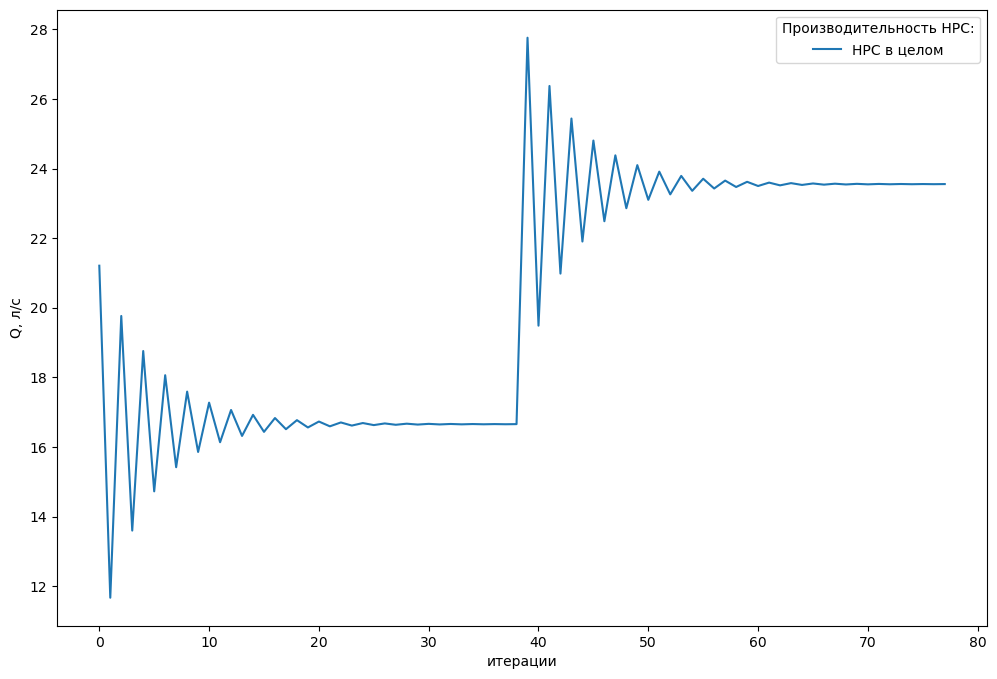

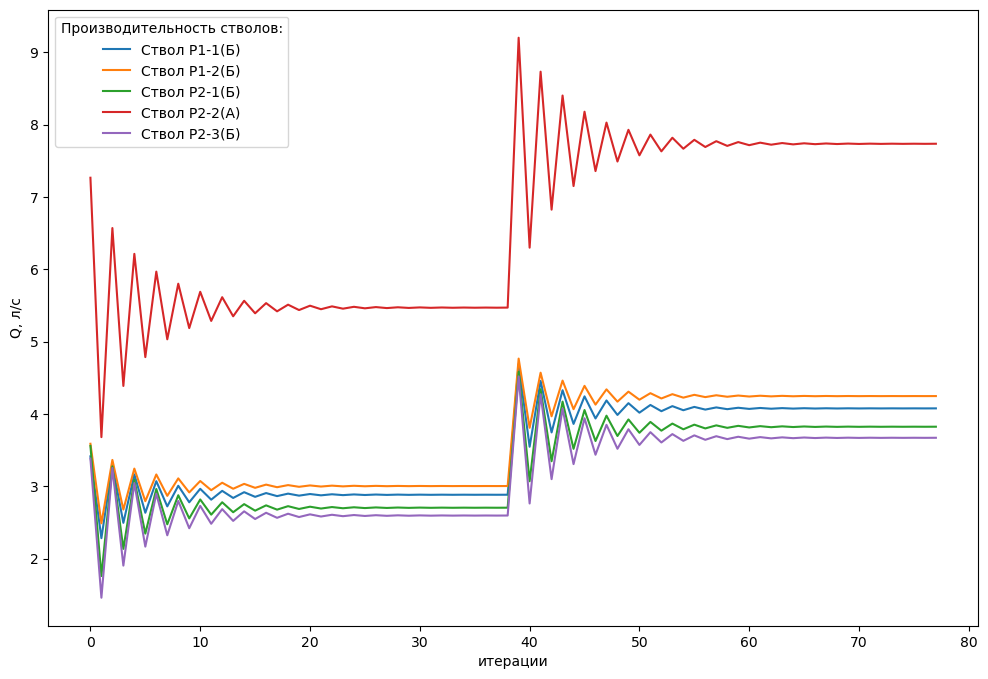

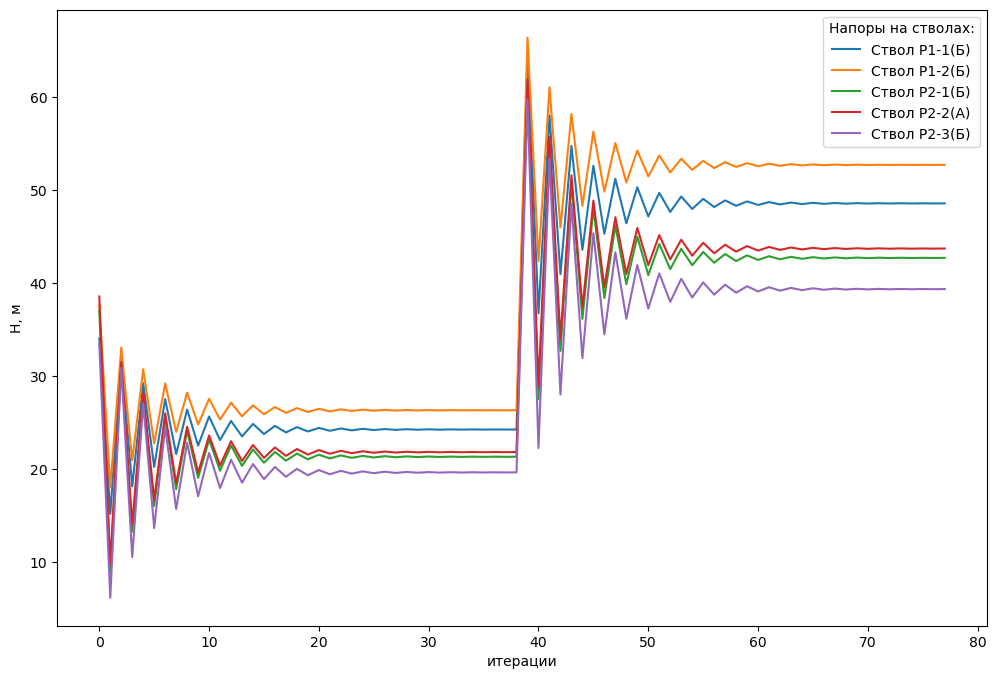

In [25]:
# Выводим графики (процесса приведения модели в стационарное состояние)
plotModelState()

## Эксперимент 1-3


Условия:
* Перекроем ствол А (№4 в модели или nozzle_22)

Задача:
* Рассчитать общий расход модели
* Рассчитать расходы на приборах подачи воды

итераций потребовалось: 7
Производительность насоса:  17.91 л/с
Производительность Ствол Р1-1(Б): 4.45 л/с
Производительность Ствол Р1-2(Б): 4.63 л/с
Производительность Ствол Р2-1(Б): 4.51 л/с
Производительность Ствол Р2-2(А): 0.0 л/с
Производительность Ствол Р2-3(Б): 4.33 л/с


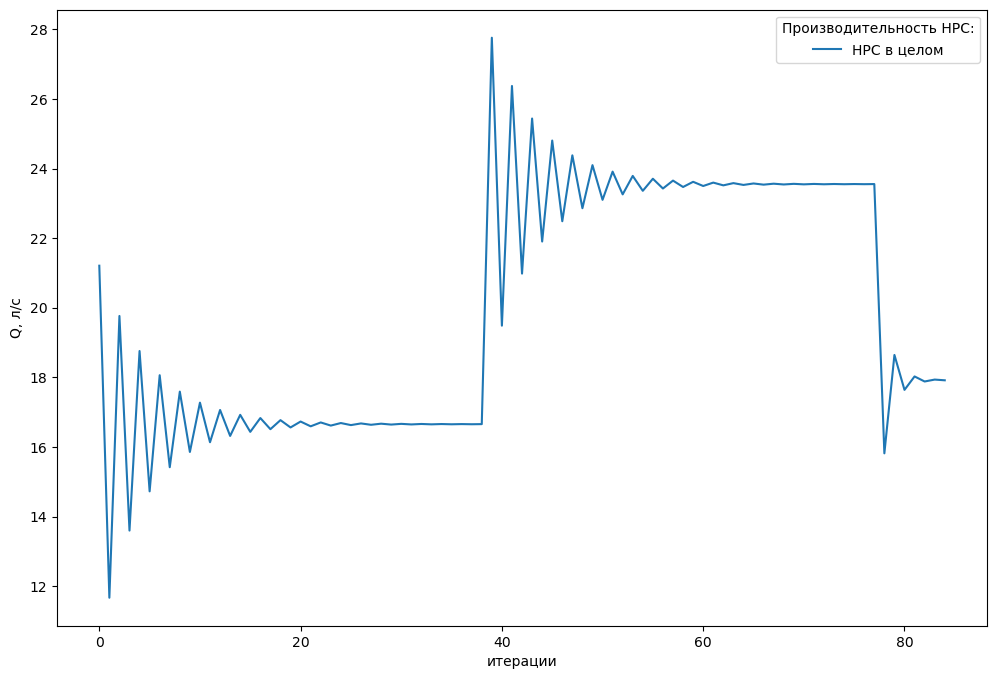

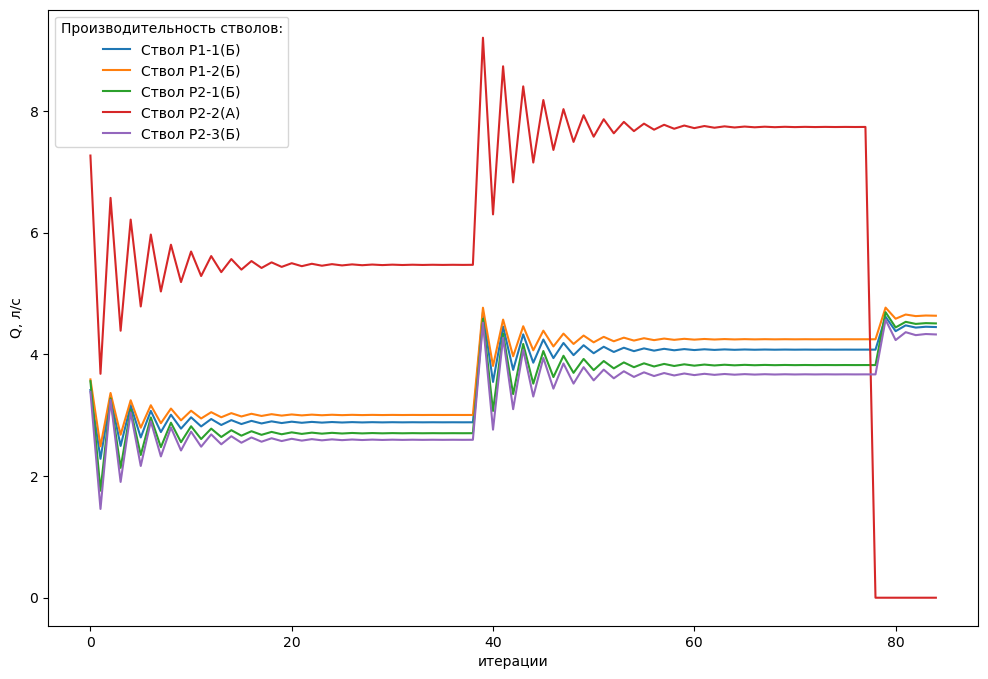

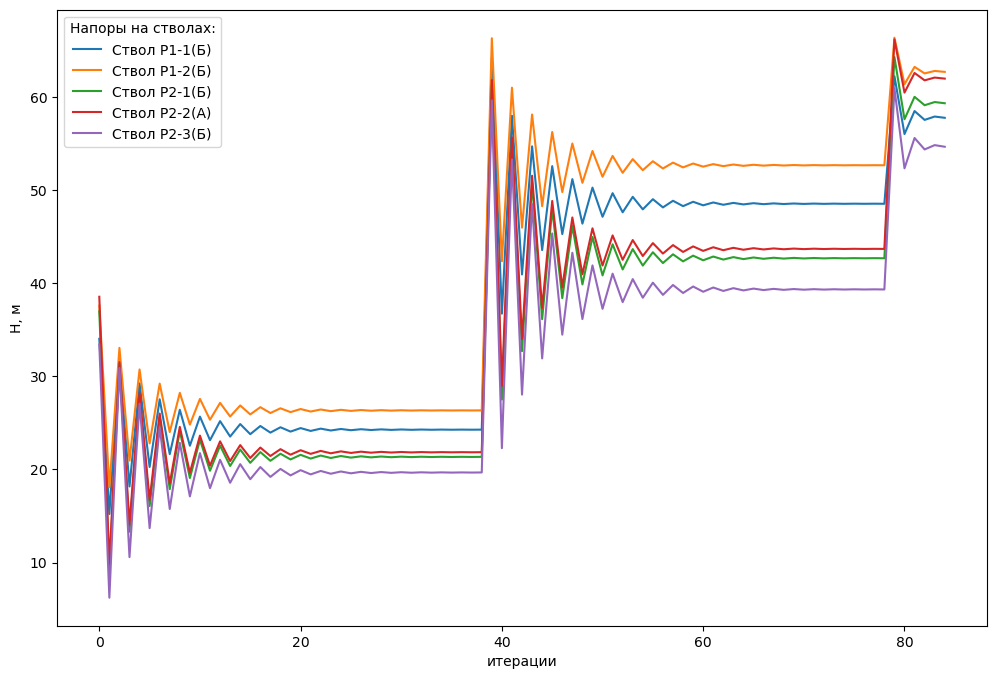

In [26]:
# Устанавливаем проводимость насадка ствола А = 0
nozzle_22.p = 0

# Рассчитываем параметры модели
_, results = model.calc(accuracy=0.05, fixStates=True)
print(f"итераций потребовалось: {results['iters']}")


# Печатаем итоговые расходы:
print("="*20)
printElementsQ()
plotModelState()